# Image Color Compression — 03 Model Building

We compress each image to k ∈ {2, 4, 8, 16, 32, 64} colours with K-Means and measure:

MSE — mean squared error vs the original (lower = better).
PSNR (dB) — peak signal-to-noise ratio (higher = better; >30 dB is visually near-lossless).

All numbers below are produced by running the code, not assumed.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd

In [4]:
import cv2

butterfly = cv2.imread("Dataset/butterfly.jpeg")
barnowl = cv2.imread("Dataset/barnowl.jpeg")

print(butterfly.shape, butterfly.dtype)
print(barnowl.shape, barnowl.dtype)

(529, 529, 3) uint8
(516, 387, 3) uint8


In [6]:
K_VALUES = [2, 4, 8, 16, 32, 64]

# 1. Quality vs compression table 

In [8]:
from sklearn.cluster import KMeans

pixels = butterfly.reshape(-1, 3)

results_butterfly = []

rng = np.random.RandomState(42)

for k in K_VALUES:

    start = time.time()

    sample_idx = rng.choice(len(pixels), 10000, replace=False)
    sample_pixels = pixels[sample_idx]

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(sample_pixels)

    labels = kmeans.predict(pixels)

    compressed_pixels = kmeans.cluster_centers_[labels]

    compressed = compressed_pixels.reshape(butterfly.shape).astype(np.uint8)

    mse = np.mean(
        (butterfly.astype(np.float32) - compressed.astype(np.float32)) ** 2
    )

    if mse == 0:
        psnr = np.inf
    else:
        psnr = 20 * np.log10(255.0 / np.sqrt(mse))

    elapsed = time.time() - start

    bpp = np.log2(k)
    ratio = 24 / bpp

    results_butterfly.append({
        "k": k,
        "mse": mse,
        "psnr": psnr,
        "bpp": bpp,
        "ratio": ratio,
        "time_sec": elapsed
    })

results_butterfly = pd.DataFrame(results_butterfly)

results_butterfly

,k,mse,psnr,bpp,ratio,time_sec
0,2,1666.107300,15.913774,1.0,24.0,0.286308
1,4,413.385895,21.967247,2.0,12.0,0.070776
2,8,205.975998,24.992637,3.0,8.0,0.158600
3,16,102.989761,28.002863,4.0,6.0,0.163751
4,32,56.744736,30.591548,5.0,4.8,0.291581
5,64,34.248138,32.784434,6.0,4.0,0.470285


# 2. Visual comparison

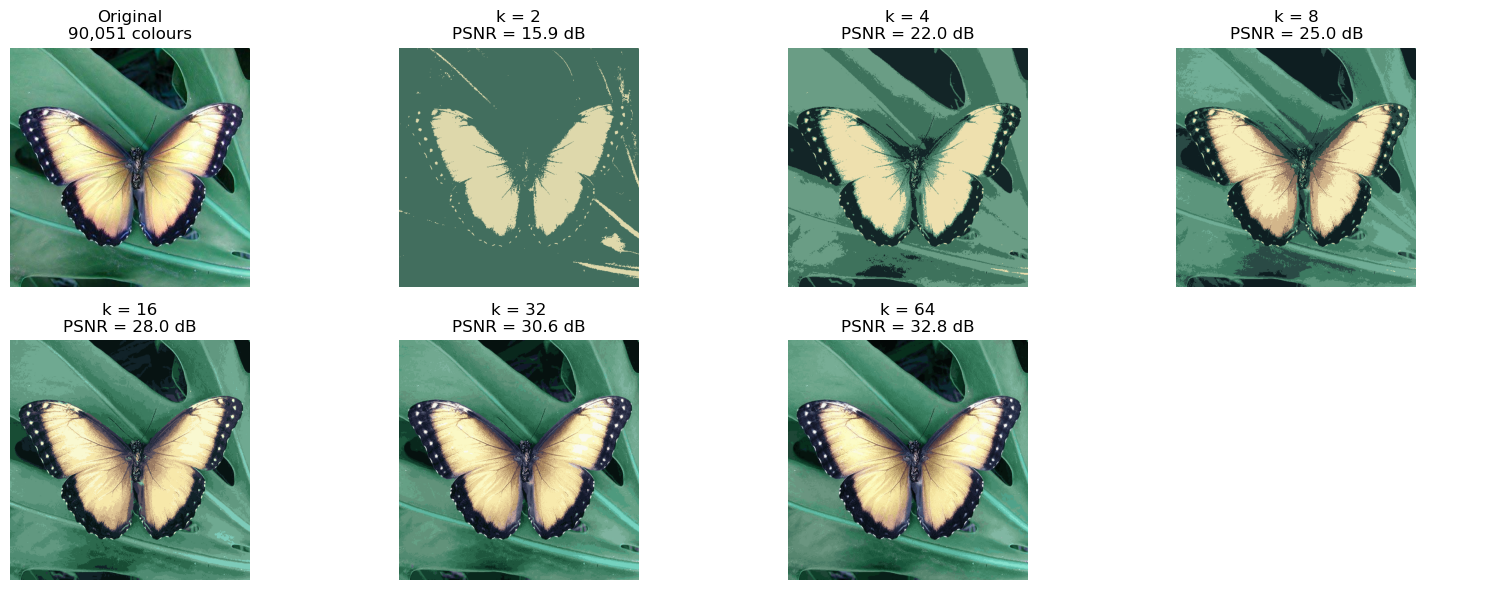

In [10]:
pixels = butterfly.reshape(-1, 3)

unique_colors = len(np.unique(pixels, axis=0))

rng = np.random.RandomState(42)

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
axes = axes.ravel()

axes[0].imshow(butterfly)
axes[0].set_title(f"Original\n{unique_colors:,} colours")
axes[0].axis("off")

for ax, k in zip(axes[1:], K_VALUES):

    sample_idx = rng.choice(len(pixels), 10000, replace=False)
    sample_pixels = pixels[sample_idx]

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(sample_pixels)

    labels = kmeans.predict(pixels)
    compressed_pixels = kmeans.cluster_centers_[labels]
    compressed = compressed_pixels.reshape(butterfly.shape).astype(np.uint8)

    mse = np.mean(
        (butterfly.astype(np.float32) - compressed.astype(np.float32)) ** 2
    )

    if mse == 0:
        psnr = np.inf
    else:
        psnr = 20 * np.log10(255.0 / np.sqrt(mse))

    ax.imshow(compressed)
    ax.set_title(f"k = {k}\nPSNR = {psnr:.1f} dB")
    ax.axis("off")

axes[-1].axis("off")

plt.tight_layout()
plt.show()

# 3. MSE and PSNR vs k

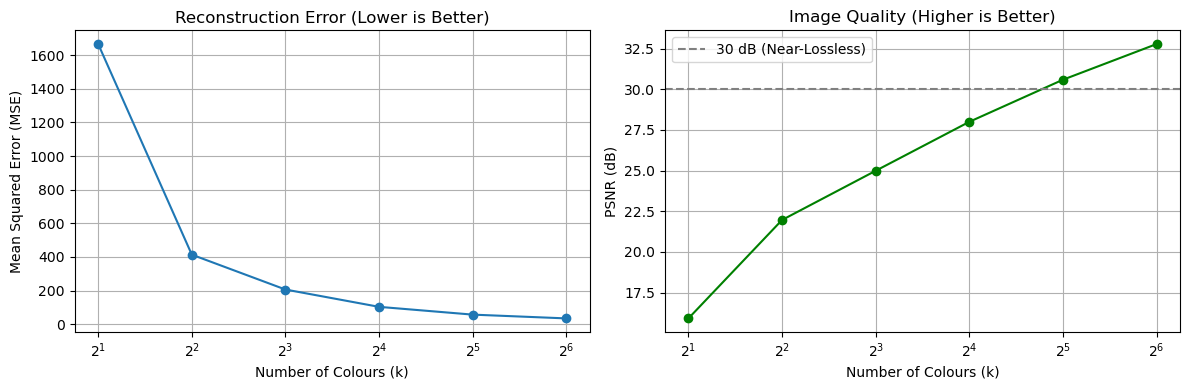

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(results_butterfly['k'], results_butterfly['mse'], 'o-')
ax[0].set_xscale('log', base=2)
ax[0].set_xlabel('Number of Colours (k)')
ax[0].set_ylabel('Mean Squared Error (MSE)')
ax[0].set_title('Reconstruction Error (Lower is Better)')
ax[0].grid(True)

ax[1].plot(results_butterfly['k'], results_butterfly['psnr'], 'o-', color='green')
ax[1].set_xscale('log', base=2)
ax[1].axhline(30, linestyle='--', color='gray', label='30 dB (Near-Lossless)')
ax[1].set_xlabel('Number of Colours (k)')
ax[1].set_ylabel('PSNR (dB)')
ax[1].set_title('Image Quality (Higher is Better)')
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

In [14]:
trade = results_butterfly[['k', 'psnr']].copy()

trade

,k,psnr
0,2,15.913774
1,4,21.967247
2,8,24.992637
3,16,28.002863
4,32,30.591548
5,64,32.784434


# 4. The learned palette 

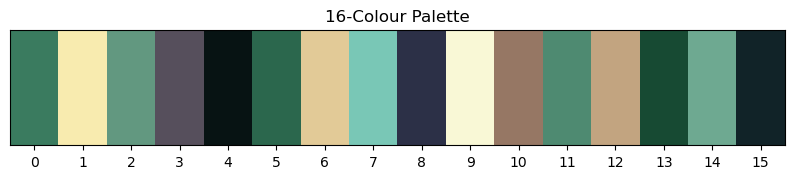

In [16]:
pixels = butterfly.reshape(-1, 3)

rng = np.random.RandomState(42)
sample_idx = rng.choice(len(pixels), 10000, replace=False)
sample_pixels = pixels[sample_idx]

km16 = KMeans(
    n_clusters=16,
    random_state=42,
    n_init=10
)

km16.fit(sample_pixels)

labels = km16.predict(pixels)
compressed_pixels = km16.cluster_centers_[labels]
comp16 = compressed_pixels.reshape(butterfly.shape).astype(np.uint8)

palette = km16.cluster_centers_.astype(np.uint8)

fig, ax = plt.subplots(figsize=(10, 1.5))

ax.imshow(palette[np.newaxis, :, :], aspect='auto')
ax.set_title("16-Colour Palette")
ax.set_yticks([])
ax.set_xticks(range(16))

plt.show()

# Second image

In [18]:
pixels = barnowl.reshape(-1, 3)

results_barnowl = []

rng = np.random.RandomState(42)

for k in K_VALUES:

    start = time.time()

    sample_idx = rng.choice(len(pixels), 10000, replace=False)
    sample_pixels = pixels[sample_idx]

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(sample_pixels)

    labels = kmeans.predict(pixels)
    compressed_pixels = kmeans.cluster_centers_[labels]
    compressed = compressed_pixels.reshape(barnowl.shape).astype(np.uint8)

    mse = np.mean(
        (barnowl.astype(np.float32) - compressed.astype(np.float32)) ** 2
    )

    if mse == 0:
        psnr = np.inf
    else:
        psnr = 20 * np.log10(255.0 / np.sqrt(mse))

    elapsed = time.time() - start

    results_barnowl.append({
        "k": k,
        "mse": mse,
        "psnr": psnr,
        "time_sec": elapsed
    })

results_barnowl = pd.DataFrame(results_barnowl)

results_barnowl

,k,mse,psnr,time_sec
0,2,1392.043701,16.694275,0.078412
1,4,414.476990,21.955800,0.077477
2,8,199.380234,25.133982,0.127633
3,16,94.235687,28.388649,0.174354
4,32,48.610165,31.263533,0.278405
5,64,27.244751,33.777976,0.469402


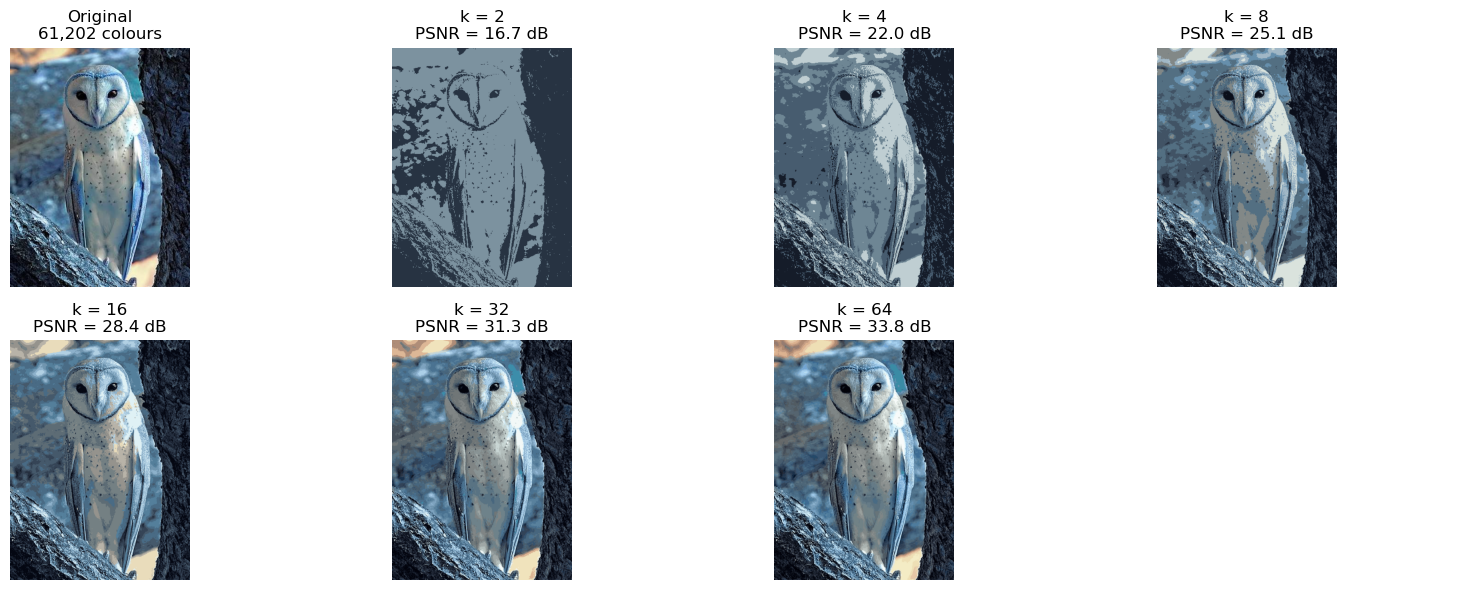

In [20]:
pixels = barnowl.reshape(-1, 3)

unique_colors = len(np.unique(pixels, axis=0))

rng = np.random.RandomState(42)

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
axes = axes.ravel()

axes[0].imshow(barnowl)
axes[0].set_title(f"Original\n{unique_colors:,} colours")
axes[0].axis("off")

for ax, k in zip(axes[1:], K_VALUES):

    sample_idx = rng.choice(len(pixels), 10000, replace=False)
    sample_pixels = pixels[sample_idx]

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(sample_pixels)

    labels = kmeans.predict(pixels)
    compressed_pixels = kmeans.cluster_centers_[labels]
    compressed = compressed_pixels.reshape(barnowl.shape).astype(np.uint8)

    mse = np.mean(
        (barnowl.astype(np.float32) - compressed.astype(np.float32)) ** 2
    )

    if mse == 0:
        psnr = np.inf
    else:
        psnr = 20 * np.log10(255.0 / np.sqrt(mse))

    ax.imshow(compressed)
    ax.set_title(f"k = {k}\nPSNR = {psnr:.1f} dB")
    ax.axis("off")

axes[-1].axis("off")

plt.tight_layout()
plt.show()